# Photonic Cavity Analysis Workflow

This notebook provides a comprehensive analysis workflow for photonic cavities using Tidy3D simulations. The workflow includes:

1. **Simulation Setup** - Geometry, materials, sources, and monitors
2. **Simulation Execution** - Running the electromagnetic simulation
3. **Q-Factor Analysis** - Ringdown analysis for quality factors
4. **Mode Volume Analysis** - Effective mode volume and Purcell factors
5. **Polarization Analysis** - Far-field polarization properties

## Key Features
- Modular, reusable components
- Idempotent execution (won't re-run if results exist)
- Comprehensive error handling
- Configurable parameters
- Integration with all analysis modules

## Usage
Run cells sequentially, or use the master workflow function at the end for complete automation.


In [1]:
# Import required modules
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Add modules directory to path
sys.path.append('modules')

# Import our analysis modules
from modules.simulation_setup import SimulationSetup, create_simulation_setup
from modules.simulation_runner import SimulationRunner, run_simulation_from_file
from modules.q_factor_analysis import QFactorAnalyzer, analyze_q_factor
from modules.mode_volume_analysis import ModeVolumeAnalyzer, analyze_mode_volume
from modules.polarization_analysis import PolarizationAnalyzer, analyze_polarization
from modules.nearfield_analysis import NearFieldAnalyzer, analyze_nearfield
from modules.farfield_analysis import FarFieldAnalyzer, analyze_farfield
from modules.collection_efficiency_analysis import CollectionEfficiencyAnalyzer, analyze_collection_efficiency

print("✓ All modules imported successfully")


✓ All modules imported successfully


In [2]:
# CRITICAL: If you get errors, run this cell to reload the modules
# This is needed because Jupyter caches imported modules
import importlib
import sys

# Force reload all modules
if 'modules.q_factor_analysis' in sys.modules:
    importlib.reload(sys.modules['modules.q_factor_analysis'])
if 'modules.mode_volume_analysis' in sys.modules:
    importlib.reload(sys.modules['modules.mode_volume_analysis'])

# Import the modules
import modules.q_factor_analysis
import modules.mode_volume_analysis
from modules.q_factor_analysis import QFactorAnalyzer, analyze_q_factor
from modules.mode_volume_analysis import ModeVolumeAnalyzer, analyze_mode_volume

print("✓ Modules force-reloaded successfully - all fixes applied")
print("  - JSON serialization fix for complex numbers")
print("  - Array shape fix for mode volume analysis")


✓ Modules force-reloaded successfully - all fixes applied
  - JSON serialization fix for complex numbers
  - Array shape fix for mode volume analysis


## ⚠️ Important: Module Reloading

**If you encounter any errors, you MUST run the cell above to reload the modules.**

Jupyter notebooks cache imported modules, so changes to the module files won't take effect until you reload them. The reload cell above will:

1. Force reload all analysis modules
2. Apply the latest fixes for:
   - JSON serialization of complex numbers
   - Array shape matching in mode volume analysis

**Always run the reload cell before running analysis cells if you get errors!**


## Configuration Parameters

Set the key parameters for your analysis here. Modify these values as needed for your specific cavity design.


In [3]:
# Configuration parameters
CONFIG = {
    # Cavity geometry
    'thickness_um': 0.14,        # Cavity thickness in micrometers
    'wavelength_um': 0.62,       # Analysis wavelength in micrometers
    
    # Simulation parameters
    'run_time_ps': 10.0,         # Simulation run time in picoseconds
    'task_name': 'photonic_cavity_simulation',  # Tidy3D task name
    
    # Analysis parameters
    'NA': 0.65,                  # Numerical aperture for polarization analysis
    'n_bg': 1.0,                 # Background refractive index
    
    # File names (auto-generated based on thickness)
    'sim_file': f"simulation_{0.14}um.json",
    'results_file': f"results_{0.14}um.hdf5"
}

print("Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")


Configuration:
  thickness_um: 0.14
  wavelength_um: 0.62
  run_time_ps: 10.0
  task_name: photonic_cavity_simulation
  NA: 0.65
  n_bg: 1.0
  sim_file: simulation_0.14um.json
  results_file: results_0.14um.hdf5


## Step 1: Simulation Setup

Create the Tidy3D simulation with geometry, materials, sources, and monitors. This step is idempotent - it won't recreate the simulation if the file already exists.


🔧 SETTING UP GEOMETRY PARAMETERS
✓ Geometry parameters loaded
  - Cavity thickness: 0.14 µm
  - Wavelength: 0.62 µm
  - Optimized padding: x=[-5.0, -5.0], y=[2.0, 2.0], z=[2.0, 2.0]

🔬 Creating diamond medium...
  - n(λ=0.620 µm) = 2.414000 (correct for diamond at 620nm)
  - Using constant permittivity (narrowband simulation)

🚀 Creating complete simulation...

📐 Extracting geometry from GDS files...
  - Using cell: TOP
  - Original bbox: x[-15.675, 15.675], y[-0.150, 0.150]
  - Geometry bbox: x[-15.675, 15.675], y[-0.150, 0.150]
  - Simulation domain: left=-10.675, right=10.675, bottom=-2.150, top=2.150
  - X truncation: 31.350 → 21.350 µm (reduced by 10.000 µm)
  - Simulation size: (21.350, 4.300, 4.140) µm
  - Simulation center: (0.000, 0.000, 0.000) µm

🏗️  Creating core structure...
  - Core rectangle created with 4 vertices
  - Thickness: 0.14 µm

🕳️  Creating hole structures...
  - Using holes cell: Unnamed_48
  - Imported 100 hole polygon(s)
  - Created 1 hole structure(s)
  - 

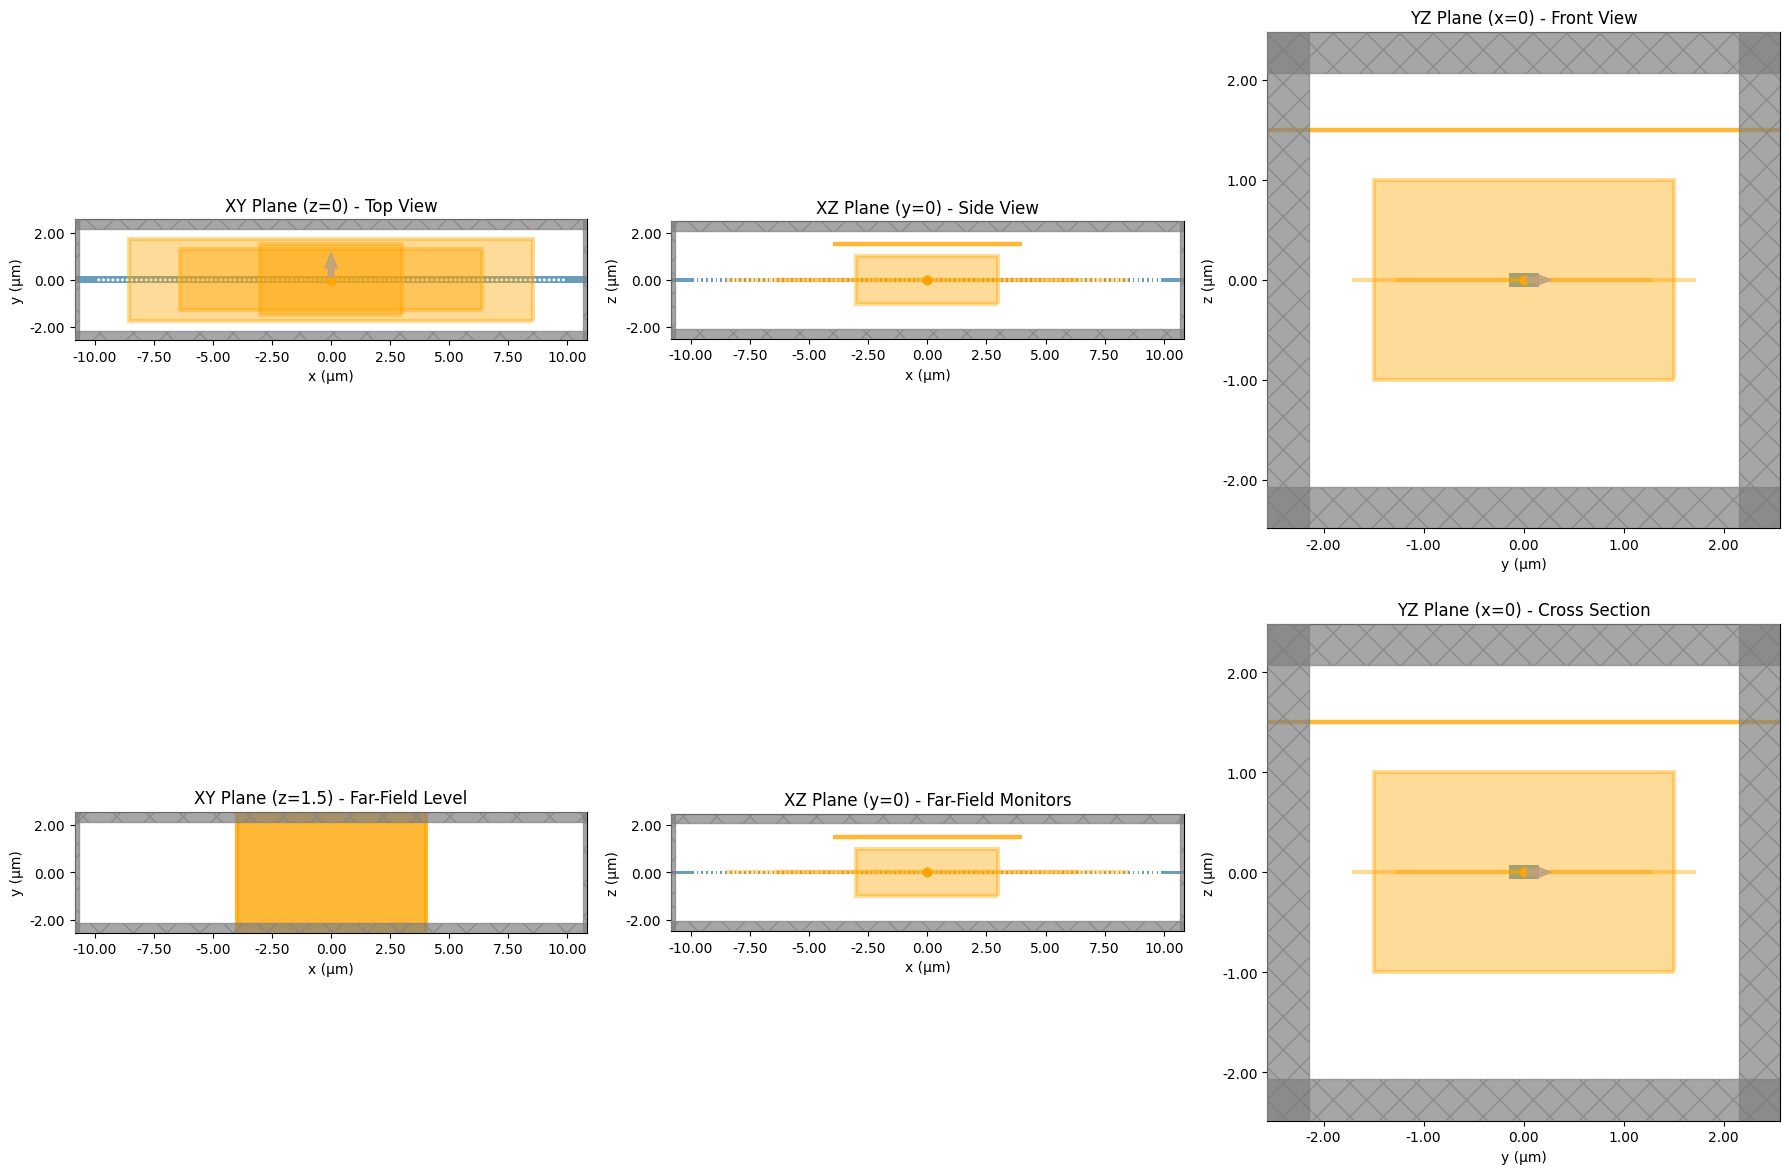

✓ Simulation setup visualization saved to simulation_setup.png
✓ Simulation setup complete: simulation_0.14um.json


In [4]:
# Create simulation setup
simulation = create_simulation_setup(
    thickness_um=CONFIG['thickness_um'],
    wavelength_um=CONFIG['wavelength_um'],
    run_time_ps=CONFIG['run_time_ps'],
    save_file=CONFIG['sim_file'],
    visualize=True
)

print(f"✓ Simulation setup complete: {CONFIG['sim_file']}")


🔬 NEAR-FIELD ANALYSIS
✓ Field data loaded
  - Field shape: (901, 93, 1)
  - X range: -6.417 to 6.417 µm
  - Y range: -1.291 to 1.291 µm
  - Max intensity: 1.18e+11
  - Total power: 7.26e+12

📊 Field confinement analysis:
  - Gaussian fitting failed: too many indices for array: array is 1-dimensional, but 2 were indexed
  - Simple 1/e² width (x): 0.357 µm
  - Simple 1/e² width (y): 1.996 µm
  - Confinement area: 0.713 µm²
  - Aspect ratio (x/y): 0.18

📐 Mode parameters:
  - Mode area: 61.702 µm²
  - Mode area (λ²): 160.514
  - Effective index: 2.40

📈 Field quality metrics:
  - Field uniformity (std/mean): 7.689
  - Ex fraction: 0.328
  - Ey fraction: 0.672
  - Ez fraction: 0.000
  - Field concentration (top 10%): 0.995

📊 Creating near-field analysis plots...


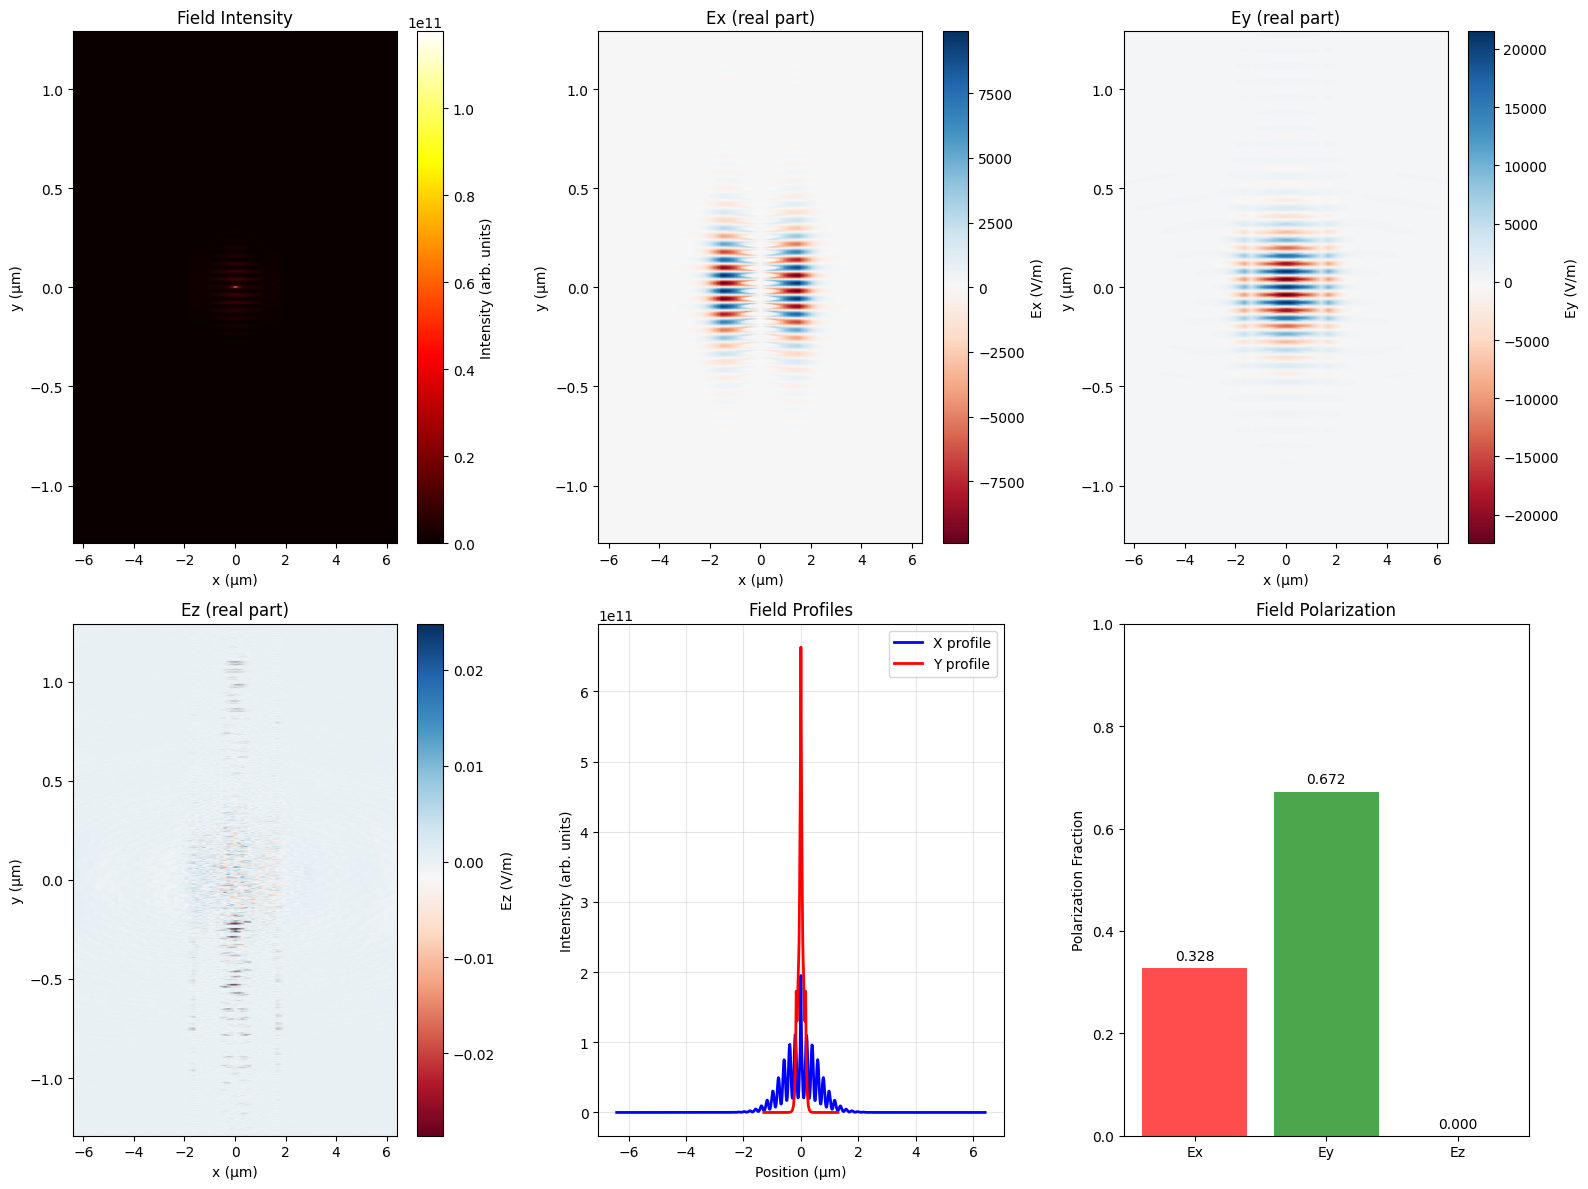

✓ Near-field analysis plots saved to 'nearfield_analysis.png'
✓ Near-field analysis results saved to nearfield_analysis_results.json
Near-field analysis results:
  Confinement area: 0.713 µm²
  Mode area: 61.702 µm²
  Field uniformity: 7.689
  Field concentration: 0.995


In [5]:
# Near-field analysis
nf_results = analyze_nearfield(
    data_path=CONFIG['results_file'],
    monitor_name="field_near",
    wavelength_um=CONFIG['wavelength_um'],
    save_results=True,
    create_plots=True
)

print("Near-field analysis results:")
print(f"  Confinement area: {nf_results['confinement']['confinement_area_um2']:.3f} µm²")
print(f"  Mode area: {nf_results['mode_parameters']['mode_area_um2']:.3f} µm²")
print(f"  Field uniformity: {nf_results['quality_metrics']['field_uniformity']:.3f}")
print(f"  Field concentration: {nf_results['quality_metrics']['field_concentration']:.3f}")


🌐 FAR-FIELD ANALYSIS
✓ Found monitor: farfield_cartesian
✓ Found monitor: farfield_kspace
✓ Found monitor: farfield_angles

--- Analyzing farfield_cartesian ---
  - Intensity range: 2.48e-08 to 2.48e-08
  - Total intensity: 6.20e-05
  - Field shape: (50, 50, 1)

--- Analyzing farfield_kspace ---
  - Intensity range: 7.65e-12 to 3.23e-08
  - Total intensity: 8.34e-06
  - Field shape: (40, 40)

--- Analyzing farfield_angles ---
  - Warning: Could not calculate beam width: index 189 is out of bounds for axis 0 with size 100
  - Directivity: 0.00
  - Beam width: 0.0°
  - Intensity range: 8.40e-12 to 3.31e-08
  - Total intensity: 1.54e-04
  - Field shape: (100, 200)

📊 Collection efficiency analysis:
  - Total power (upper hemisphere only): 5.15e-05
  - Total power (full sphere): 1.03e-04
  - Collected power: 3.19e-05
  - Collection efficiency (upper hemisphere only): 0.620 (62.0%)
  - Collection efficiency (full sphere): 0.310 (31.0%)
  - Collection angle: ±40.5°

📊 Creating far-field anal

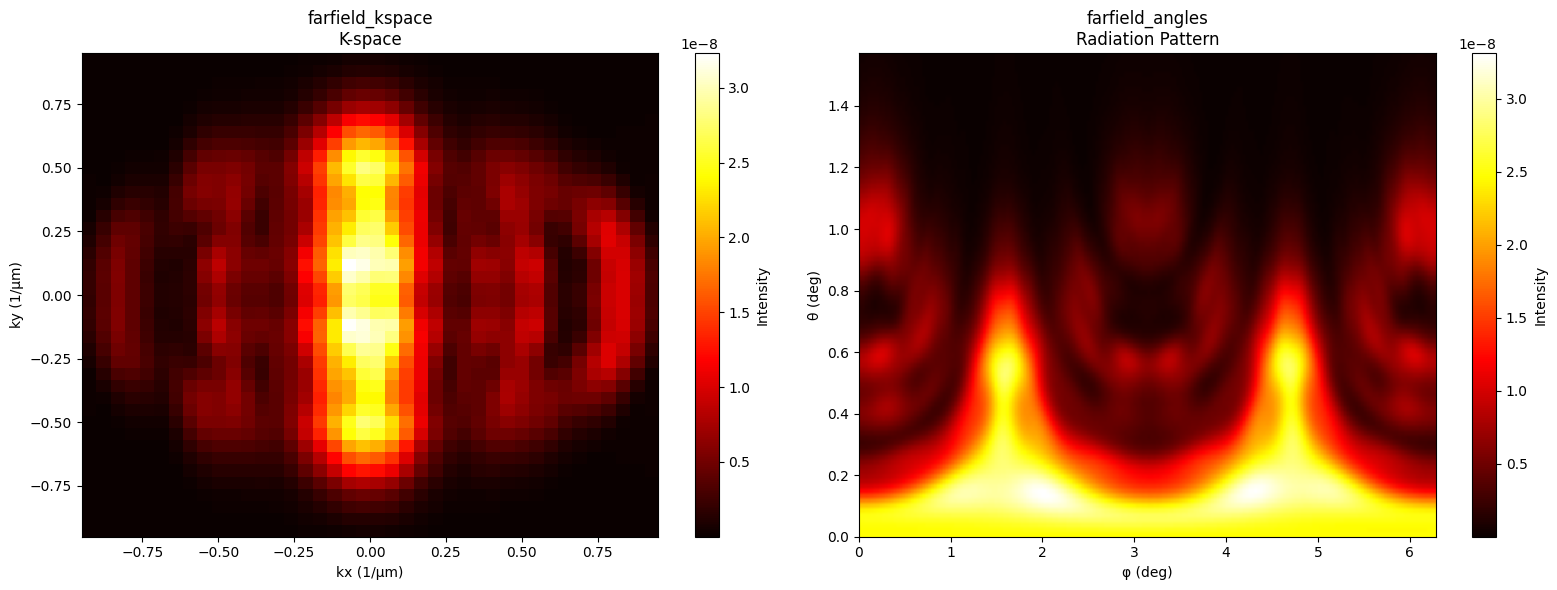


📊 Creating collection efficiency vs NA plot...


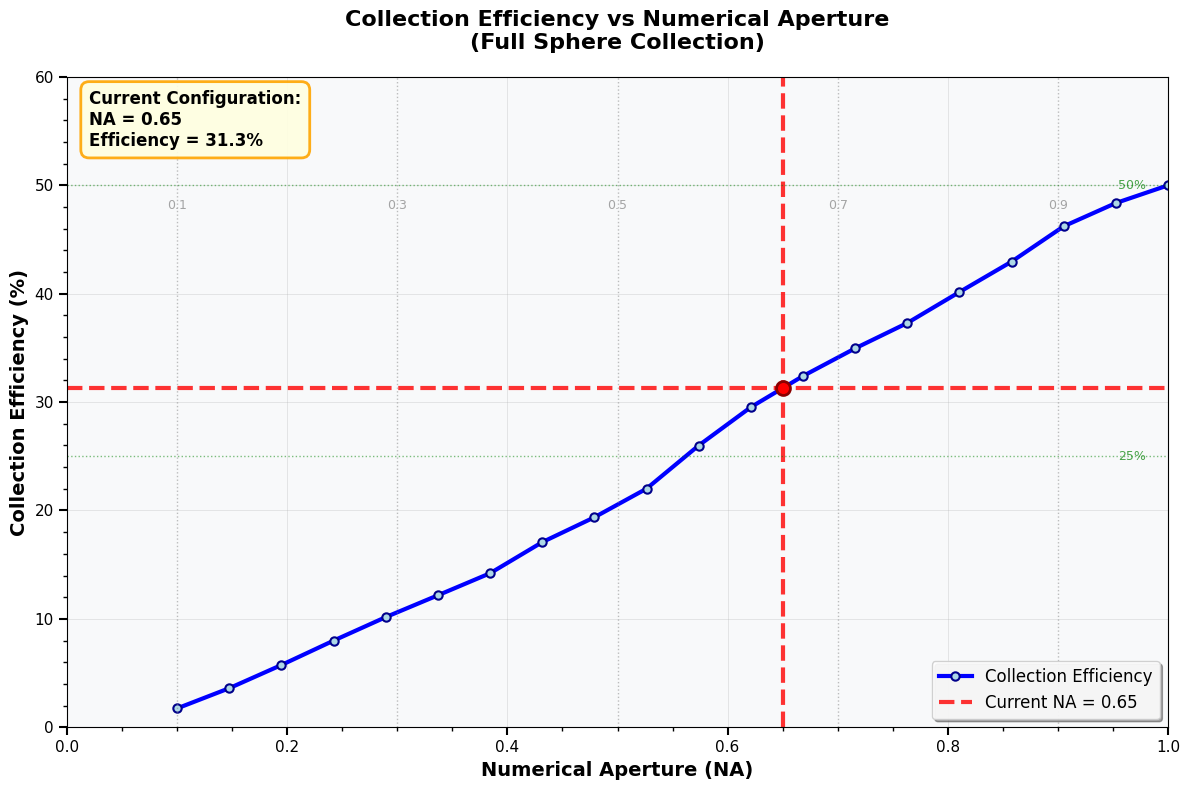

✓ Collection efficiency vs NA plot saved to 'collection_efficiency_vs_na.png'
✓ Far-field analysis results saved to farfield_analysis_results.json
Far-field analysis results:
  farfield_cartesian:
  farfield_kspace:
  farfield_angles:
    Directivity: 0.00
    Beam width: 0.0°


In [6]:
# Far-field analysis
ff_results = analyze_farfield(
    data_path=CONFIG['results_file'],
    monitor_names=['farfield_cartesian', 'farfield_kspace', 'farfield_angles'],
    wavelength_um=CONFIG['wavelength_um'],
    NA=CONFIG['NA'],
    n_bg=CONFIG['n_bg'],
    save_results=True,
    create_plots=True
)

print("Far-field analysis results:")
for monitor_name, monitor_results in ff_results.items():
    if monitor_name != 'collection_efficiency' and 'radiation_metrics' in monitor_results:
        metrics = monitor_results['radiation_metrics']
        print(f"  {monitor_name}:")
        if 'directivity' in metrics:
            print(f"    Directivity: {metrics['directivity']:.2f}")
        if 'beam_width_deg' in metrics:
            print(f"    Beam width: {metrics['beam_width_deg']:.1f}°")
        if 'NA_effective' in metrics:
            print(f"    Effective NA: {metrics['NA_effective']:.3f}")


## Step 2: Simulation Execution

Run the electromagnetic simulation. This step includes cost estimation and is idempotent - it won't re-run if results already exist.


In [7]:
# Run simulation
data = run_simulation_from_file(
    sim_file=CONFIG['sim_file'],
    results_path=CONFIG['results_file'],
    task_name=CONFIG['task_name'],
    force_rerun=False,  # Set to True to force re-run
    estimate_cost=True
)

if data is not None:
    print(f"✓ Simulation completed: {CONFIG['results_file']}")
else:
    print("❌ Simulation failed or was cancelled")


🚀 LOADING SIMULATION
Loading simulation from simulation_0.14um.json...
✓ Simulation loaded successfully
  - Structures: 2
  - Monitors: 7
  - Run time: 10.0 ps
  - Size: (21.35, 4.3, 4.14) µm

Monitors:
  1. probe: FieldTimeMonitor
  2. flux: FluxMonitor
  3. field_near: FieldMonitor
  4. farfield_cartesian: FieldProjectionCartesianMonitor
  5. farfield_kspace: FieldProjectionKSpaceMonitor
  6. farfield_angles: FieldProjectionAngleMonitor
  7. fld_3d_box: FieldMonitor

🎯 RUNNING SIMULATION
  - Task name: photonic_cavity_simulation
  - Output path: results_0.14um.hdf5
  - Run time: 10.0 ps
✓ Found existing results: results_0.14um.hdf5
  - Available monitors: ['probe', 'flux', 'field_near', 'farfield_cartesian', 'farfield_kspace', 'farfield_angles', 'fld_3d_box']
✓ Using existing results (use force_rerun=True to override)
✓ Simulation completed: results_0.14um.hdf5


## Step 3: Q-Factor Analysis

Analyze the temporal ringdown to extract quality factors using multi-mode fitting with variable projection.


🔬 Q-FACTOR RINGDOWN ANALYSIS
✓ Extracted signal data
  - Time points: 76619
  - Duration: 10.00 ps
  - Time step: 0.000 ps
✓ Prepared analysis segment
  - Tail start: peak+guard (index 233)
  - Tail duration: 9.970 ps
  - Tail points: 76386
✓ Extracted initial seeds
  - Frequency seed: 482.361589 THz
  - Decay rate seed: 1.342e+11 1/s
  - Wavelength guess: 483.536223 THz
✓ Built search grids
  - Frequency grid: 121 points
  - Decay rate grid: 81 points
✓ Single mode fit complete
  - Frequency: 482.327382 THz
  - Decay time: 7.324 ps
  - Q-factor: 11,098
  - Residual: 29.91%
  - Coverage: 1.36 e-folds
✓ Multi-mode analysis complete
  - Effective modes: 1
  - Grid residual: 29.91%
✓ Variable projection refinement complete
  - Mode 1: f=482.361592 THz, τ=7.464 ps, Q=11,310, coverage=1.34
  - Final residual: 0.36%


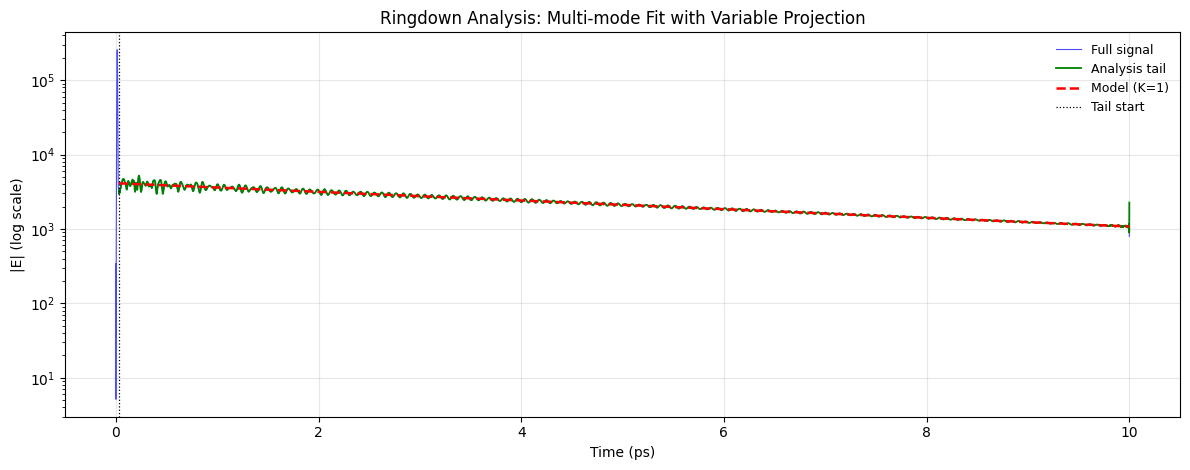

✓ Ringdown analysis plot saved to q_factor_analysis.png
✓ Q-factor analysis results saved to q_factor_results.json
Q-factor analysis results:
  Q-factors: [11310.11166787]
  Frequencies: ['482.362'] THz
  Decay times: ['7.464'] ps


In [8]:
# Q-factor analysis
q_results = analyze_q_factor(
    data_path=CONFIG['results_file'],
    wavelength_um=CONFIG['wavelength_um'],
    save_results=True
)

print("Q-factor analysis results:")
print(f"  Q-factors: {q_results['q_factors']}")
print(f"  Frequencies: {[f'{f/1e12:.3f}' for f in q_results['frequencies_hz']]} THz")
print(f"  Decay times: {[f'{t*1e12:.3f}' for t in q_results['decay_times_s']]} ps")


## Step 4: Mode Volume Analysis

Calculate the effective mode volume and Purcell factor for quantum emitter applications.


🔬 MODE VOLUME ANALYSIS
✓ Loaded 3D field data
  - Field shape: (69, 107, 423)
  - X range: -3.009 to 3.009 µm
  - Y range: -1.532 to 1.532 µm
  - Z range: -1.005 to 1.005 µm

🔧 Creating permittivity map from GDS geometry...
  - Cavity bounds: x[-15.675, 15.675] µm, y[-0.150, 0.150] µm
  - Found 100 hole polygons
  - Field shape: (z=69, y=107, x=423)
  - Permittivity map created: (69, 107, 423)
  - Core volume fraction: 0.023

📊 Computing effective mode volume...
  - Volume element: 0.000 µm³
  - Maximum ε|E|²: 6.85e+11
  - Total weighted energy: 3.17e-09
  - Effective mode volume: 4.623e-21 m³ = 0.005 µm³

🎯 Purcell Factor Analysis
  - Wavelength: 0.620 µm
  - Background index: 1.000
  - Quality factor: 11310
  - Mode volume: 0.005 µm³
  - Purcell factor: 44310.32
✓ Loaded 3D field data
  - Field shape: (69, 107, 423)
  - X range: -3.009 to 3.009 µm
  - Y range: -1.532 to 1.532 µm
  - Z range: -1.005 to 1.005 µm

🔧 Creating permittivity map from GDS geometry...
  - Cavity bounds: x[-15

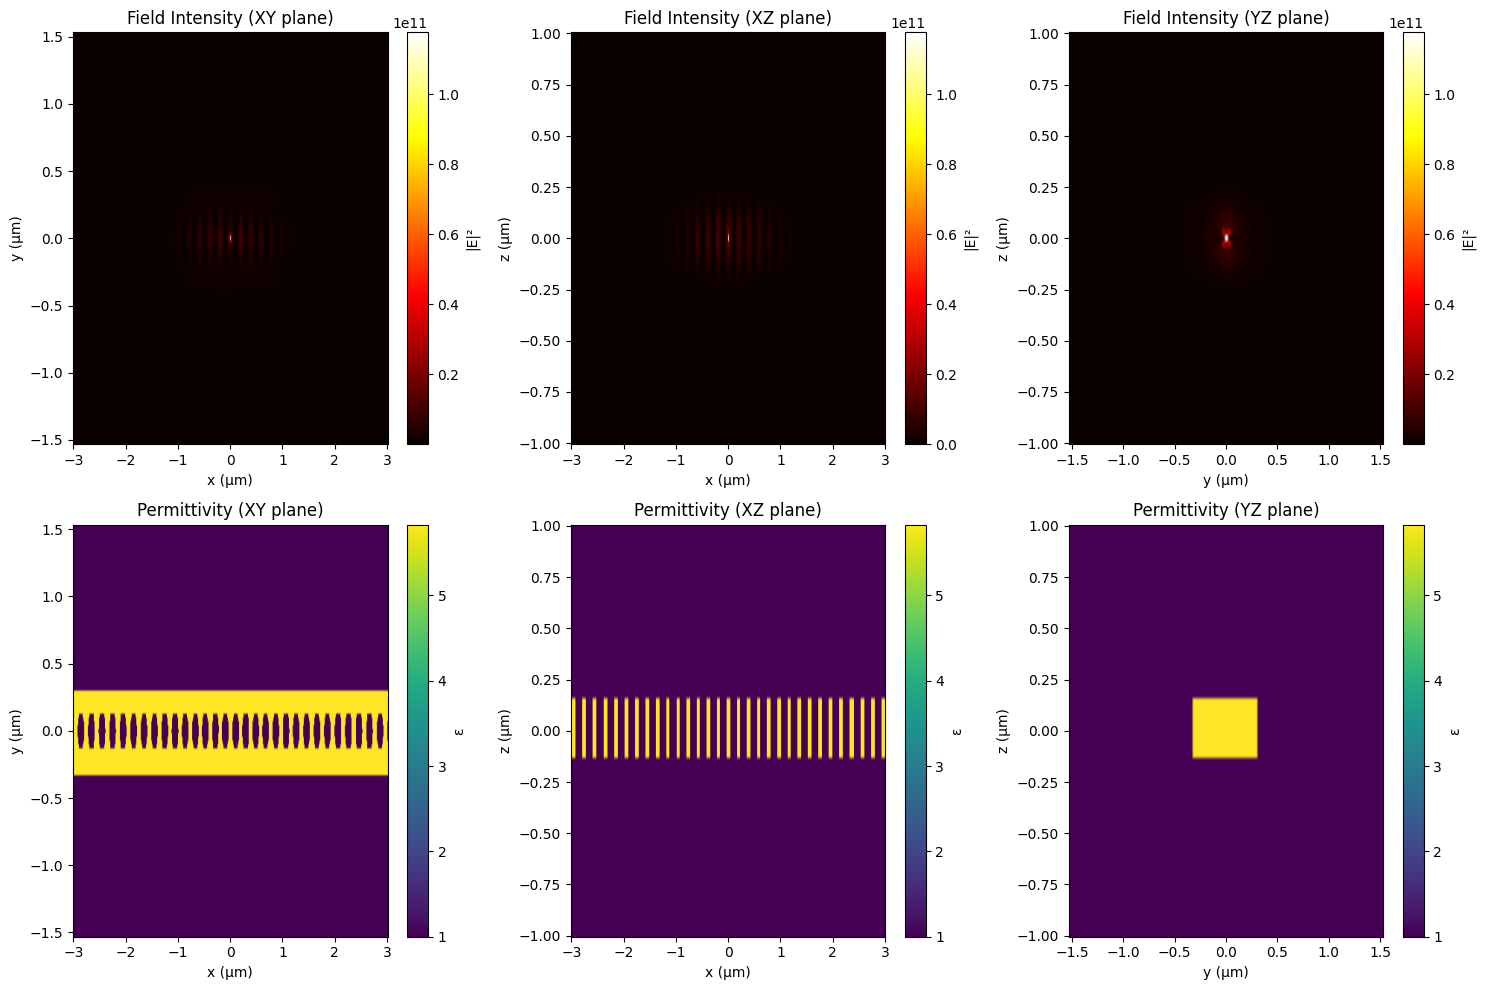

✓ Field distribution plots saved to mode_volume_field.png
✓ Mode volume analysis results saved to mode_volume_results.json
Mode volume analysis results:
  Effective mode volume: 0.005 µm³
  Purcell factor: 44310.32


In [9]:
# Mode volume analysis
Q = q_results['q_factors'][0]  # Use first mode's Q-factor
mv_results = analyze_mode_volume(
    data_path=CONFIG['results_file'],
    thickness_um=CONFIG['thickness_um'],
    wavelength_um=CONFIG['wavelength_um'],
    Q=Q,
    n_bg=CONFIG['n_bg'],
    save_results=True,
    create_plots=True
)

print("Mode volume analysis results:")
print(f"  Effective mode volume: {mv_results['effective_mode_volume_um3']:.3f} µm³")
if mv_results['purcell_factor'] is not None:
    print(f"  Purcell factor: {mv_results['purcell_factor']:.2f}")


## Step 5: Polarization Analysis

Analyze far-field polarization properties including Stokes parameters, degree of polarization, and collection efficiency.


🔬 FAR-FIELD POLARIZATION ANALYSIS
✓ Using angle monitor: farfield_angles
✓ Extracted far-field data
  - Field shape: (100, 200)
  - Theta range: 0.0° to 90.0°
  - Phi range: 0.0° to 360.0°
✓ Calculated NA cone
  - NA: 0.65
  - Background index: 1.0
  - Theta max: 40.5°
✓ Calculated polarization metrics
  - DoLP: 0.346
  - DoCP: 0.003
  - DoP: 0.346
  - Psi: 0.3°
  - Chi: -0.1°
✓ Collection efficiency: 62.25%
✓ Polarization state: weakly linear (ψ ≈ 0.3°, χ ≈ -0.1°)

📊 Creating theta-phi heatmaps...


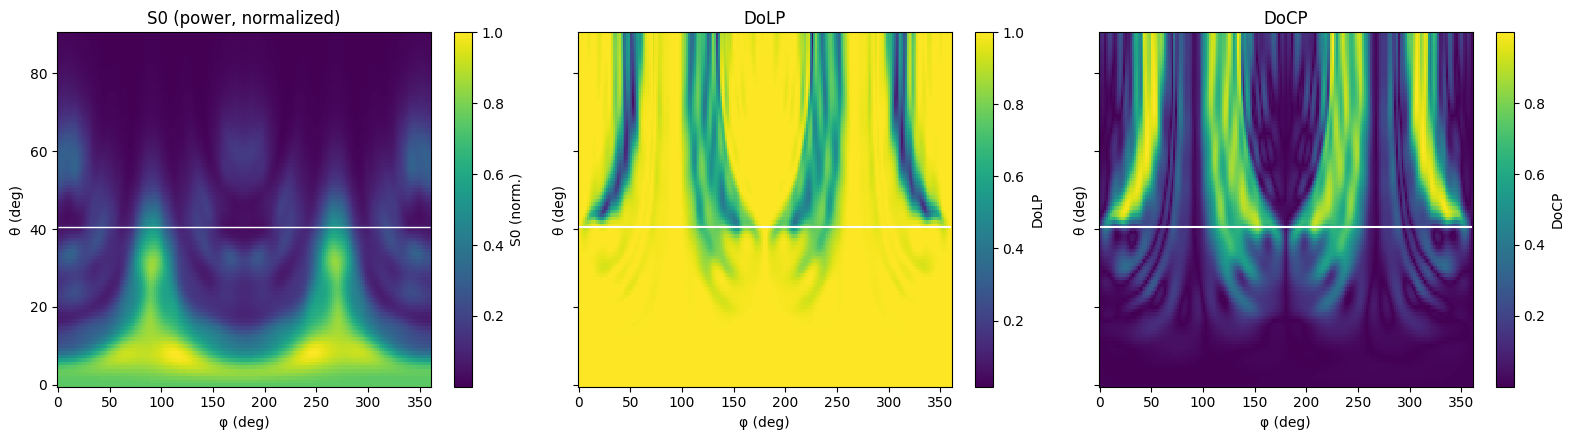

✓ Theta-phi heatmaps saved to polarization_heatmaps.png

📊 Creating azimuthal averages...


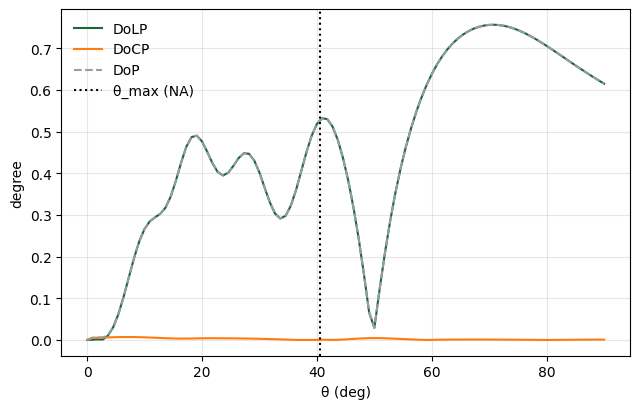

✓ Azimuthal averages saved to polarization_azimuthal.png

📊 Creating back focal plane plot...


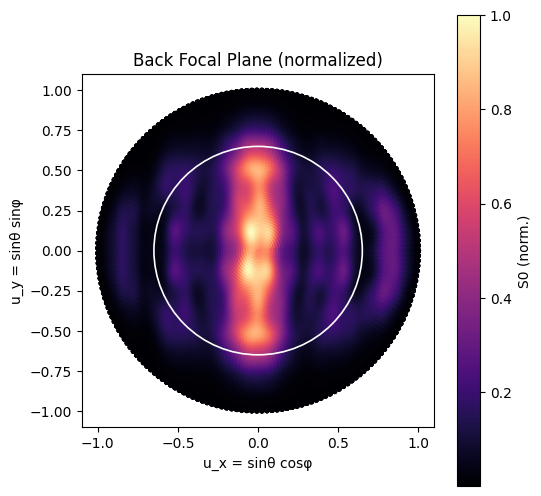

✓ Back focal plane plot saved to polarization_bfp.png

📊 Creating polarization quiver plot...


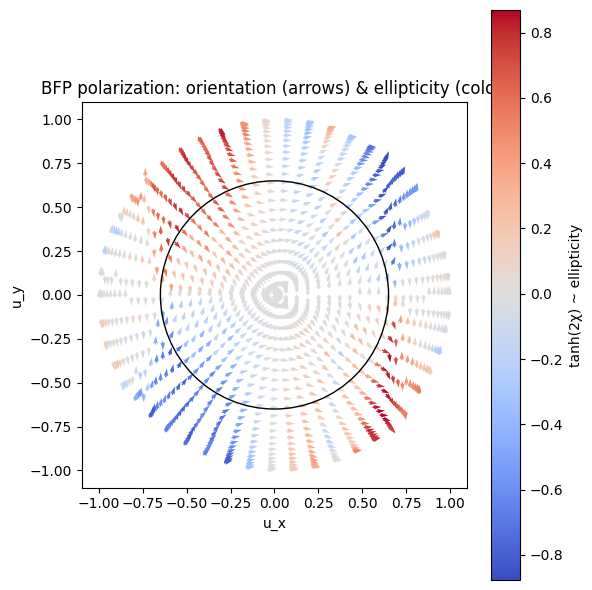

✓ Polarization quiver plot saved to polarization_bfp_quiver.png
✓ Polarization analysis results saved to polarization_results.json
Polarization analysis results:
  DoLP: 0.346
  DoCP: 0.003
  DoP: 0.346
  Collection efficiency: 62.3%


In [10]:
# Polarization analysis
pol_results = analyze_polarization(
    data_path=CONFIG['results_file'],
    wavelength_um=CONFIG['wavelength_um'],
    NA=CONFIG['NA'],
    n_bg=CONFIG['n_bg'],
    save_results=True,
    create_plots=True
)

print("Polarization analysis results:")
print(f"  DoLP: {pol_results.DoLP_avg:.3f}")
print(f"  DoCP: {pol_results.DoCP_avg:.3f}")
print(f"  DoP: {pol_results.DoP_avg:.3f}")

# Calculate collection efficiency
from modules.polarization_analysis import PolarizationAnalyzer
analyzer = PolarizationAnalyzer(CONFIG['wavelength_um'])
eta = analyzer.calculate_collection_efficiency(pol_results)
print(f"  Collection efficiency: {100*eta:.1f}%")


## Complete Workflow Function

For convenience, here's a single function that runs the entire analysis pipeline:


In [11]:
def run_complete_analysis(thickness_um=0.14, wavelength_um=0.62, run_time_ps=10.0, 
                         NA=0.65, n_bg=1.0, force_rerun=False):
    """
    Run the complete photonic cavity analysis pipeline.
    
    Args:
        thickness_um: Cavity thickness in micrometers
        wavelength_um: Analysis wavelength in micrometers
        run_time_ps: Simulation run time in picoseconds
        NA: Numerical aperture for polarization analysis
        n_bg: Background refractive index
        force_rerun: Force re-run of simulation
        
    Returns:
        Dictionary with all analysis results
    """
    print("="*80)
    print("🎯 COMPLETE PHOTONIC CAVITY ANALYSIS")
    print("="*80)
    
    # File names
    sim_file = f"simulation_{thickness_um}um.json"
    results_file = f"results_{thickness_um}um.hdf5"
    
    results = {}
    
    # Step 1: Setup simulation
    print("\n🔧 Setting up simulation...")
    simulation = create_simulation_setup(
        thickness_um=thickness_um,
        wavelength_um=wavelength_um,
        run_time_ps=run_time_ps,
        save_file=sim_file,
        visualize=False  # Skip visualization for automated run
    )
    
    # Step 2: Run simulation
    print("\n🚀 Running simulation...")
    data = run_simulation_from_file(
        sim_file=sim_file,
        results_path=results_file,
        task_name="photonic_cavity_simulation",
        force_rerun=force_rerun,
        estimate_cost=True
    )
    
    if data is None:
        print("❌ Simulation failed")
        return None
    
    # Step 3: Q-factor analysis
    print("\n🔬 Analyzing Q-factor...")
    results['q_factor'] = analyze_q_factor(
        data_path=results_file,
        wavelength_um=wavelength_um,
        save_results=True
    )
    
    # Step 4: Mode volume analysis
    print("\n📊 Analyzing mode volume...")
    Q = results['q_factor']['q_factors'][0]
    results['mode_volume'] = analyze_mode_volume(
        data_path=results_file,
        thickness_um=thickness_um,
        wavelength_um=wavelength_um,
        Q=Q,
        n_bg=n_bg,
        save_results=True,
        create_plots=False  # Skip plots for automated run
    )
    
    # Step 5: Polarization analysis
    print("\n🌐 Analyzing polarization...")
    results['polarization'] = analyze_polarization(
        data_path=results_file,
        wavelength_um=wavelength_um,
        NA=NA,
        n_bg=n_bg,
        save_results=True,
        create_plots=False  # Skip plots for automated run
    )
    
    # Summary
    print("\n" + "="*80)
    print("📋 ANALYSIS SUMMARY")
    print("="*80)
    print(f"Q-factors: {results['q_factor']['q_factors']}")
    print(f"Mode volume: {results['mode_volume']['effective_mode_volume_um3']:.3f} µm³")
    if results['mode_volume']['purcell_factor'] is not None:
        print(f"Purcell factor: {results['mode_volume']['purcell_factor']:.2f}")
    print(f"DoLP: {results['polarization'].DoLP_avg:.3f}")
    print(f"DoCP: {results['polarization'].DoCP_avg:.3f}")
    print(f"DoP: {results['polarization'].DoP_avg:.3f}")
    
    return results

# Example usage (uncomment to run):
# results = run_complete_analysis(thickness_um=0.14, wavelength_um=0.62)
